# Разведочный анализ данных (EDA)

**Проект:** Рекомендации по замене блюд

**Цель этапа:** изучить датасет, понять структуру и распределение признаков, выявить закономерности, которые пригодятся для дальнейшей разметки данных и построения моделей.



## 1. Импорт библиотек

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Настройка отображения таблиц
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

## 2. Загрузка данных



In [13]:
import csv

def load_and_fix_csv(path):
    with open(path, 'r', encoding='utf-8') as f:
        reader = csv.reader(f)
        header = next(reader)
        n_cols = len(header)
        fixed_rows = []
        for row in reader:
            if len(row) == n_cols:
                fixed_rows.append(row)
            else:
                print('Неожиданная строка, пропущена:', row)
    return pd.DataFrame(fixed_rows, columns=header)

df = load_and_fix_csv('../data/russian_food_dataset.csv')


numeric_cols = ['Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)', 'Sugars (g)', 'Sodium (mg)']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

print('Размер таблицы:', df.shape)
df.head()

Размер таблицы: (400, 10)


,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Meal_Type
0,Борщ,Суп,50,2.8,5.2,2.0,1.2,2.0,480,Обед
1,Щи из свежей капусты,Суп,35,2.0,4.5,1.2,1.0,1.5,420,Обед
2,Щи из квашеной капусты,Суп,40,2.2,4.8,1.5,1.1,0.5,520,Обед
3,Рассольник,Суп,55,3.5,5.0,2.5,0.8,0.5,580,Обед
4,Солянка мясная,Суп,98,6.5,4.2,6.0,0.5,1.0,750,Обед


## 3. Общая информация о датасете

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Food_Item          400 non-null    str    
 1   Category           400 non-null    str    
 2   Calories (kcal)    400 non-null    int64  
 3   Protein (g)        400 non-null    float64
 4   Carbohydrates (g)  400 non-null    float64
 5   Fat (g)            400 non-null    float64
 6   Fiber (g)          400 non-null    float64
 7   Sugars (g)         400 non-null    float64
 8   Sodium (mg)        400 non-null    int64  
 9   Meal_Type          400 non-null    str    
 10  Category_Grouped   400 non-null    str    
dtypes: float64(5), int64(2), str(4)
memory usage: 34.5 KB


In [16]:
print('Пропуски по столбцам:')
df.isnull().sum()

Пропуски по столбцам:


Food_Item            0
Category             0
Calories (kcal)      0
Protein (g)          0
Carbohydrates (g)    0
Fat (g)              0
Fiber (g)            0
Sugars (g)           0
Sodium (mg)          0
Meal_Type            0
Category_Grouped     0
dtype: int64

**Вывод:** пропущенных значений в данных нет

In [17]:
df.describe()

,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg)
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,163.947500,8.295250,16.472000,7.555500,1.723500,5.951000,253.027500
std,119.596983,7.185906,15.534717,9.539961,2.001816,9.233444,318.686161
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,68.000000,2.500000,4.800000,1.500000,0.300000,1.500000,54.000000
50%,145.000000,6.000000,10.600000,4.000000,1.500000,2.600000,180.000000
75%,235.750000,13.000000,25.625000,11.000000,2.500000,5.600000,420.000000
max,654.000000,31.000000,80.500000,65.200000,12.500000,68.500000,4800.000000


## 4. Распределение ключевых числовых признаков


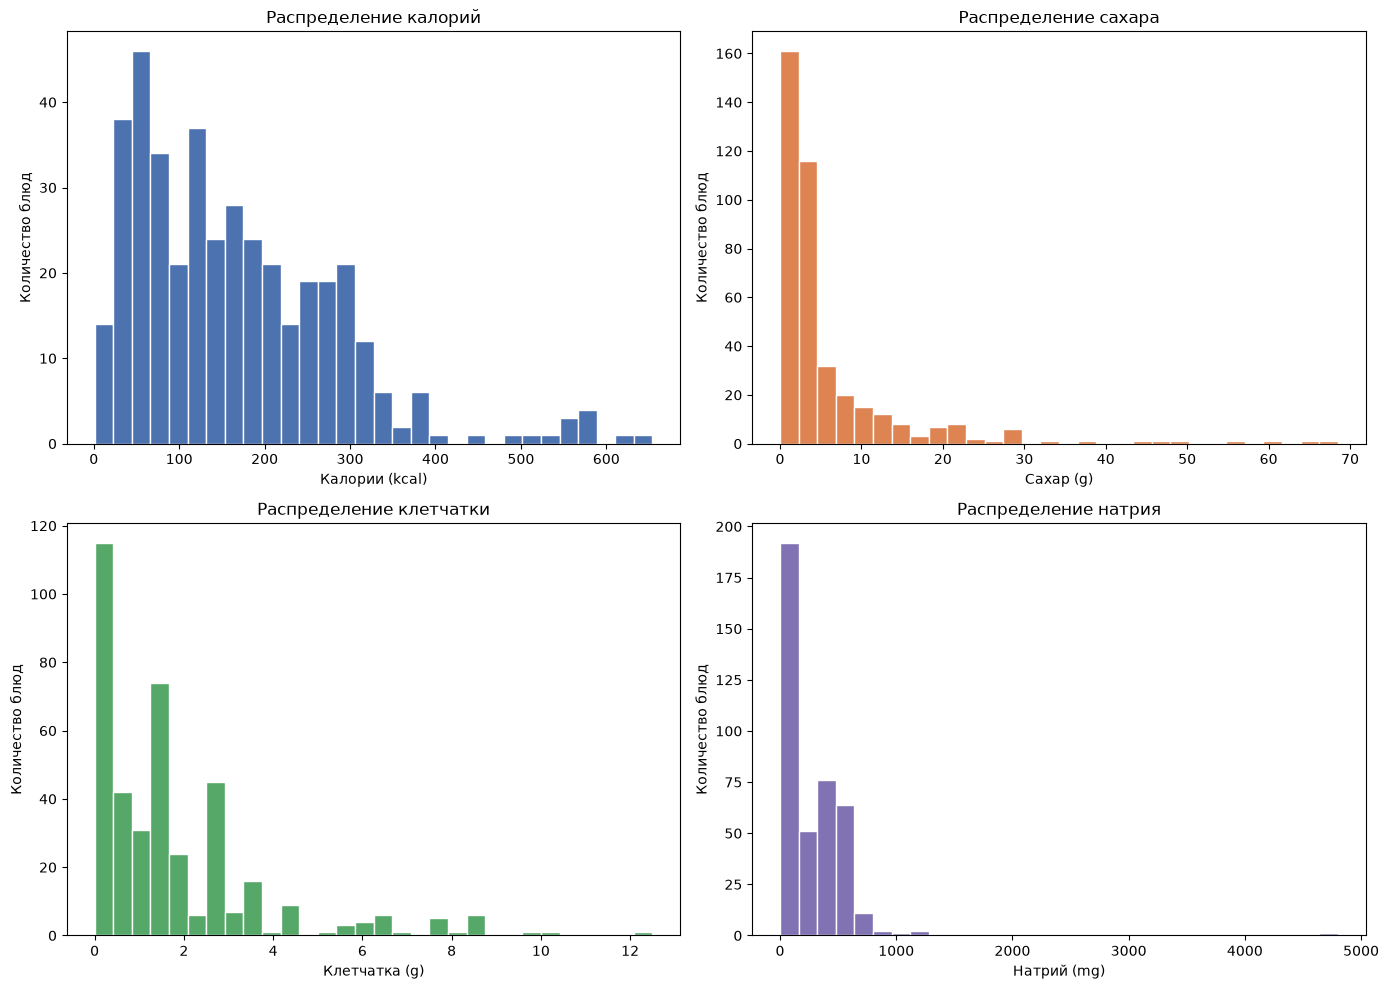

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].hist(df['Calories (kcal)'], bins=30, color='#4C72B0', edgecolor='white')
axes[0,0].set_title('Распределение калорий')
axes[0,0].set_xlabel('Калории (kcal)')
axes[0,0].set_ylabel('Количество блюд')

axes[0,1].hist(df['Sugars (g)'], bins=30, color='#DD8452', edgecolor='white')
axes[0,1].set_title('Распределение сахара')
axes[0,1].set_xlabel('Сахар (g)')
axes[0,1].set_ylabel('Количество блюд')

axes[1,0].hist(df['Fiber (g)'], bins=30, color='#55A868', edgecolor='white')
axes[1,0].set_title('Распределение клетчатки')
axes[1,0].set_xlabel('Клетчатка (g)')
axes[1,0].set_ylabel('Количество блюд')

axes[1,1].hist(df['Sodium (mg)'], bins=30, color='#8172B3', edgecolor='white')
axes[1,1].set_title('Распределение натрия')
axes[1,1].set_xlabel('Натрий (mg)')
axes[1,1].set_ylabel('Количество блюд')

plt.tight_layout()
plt.show()

**Вывод:** Все четыре признака имеют выраженную правостороннюю асимметрию, что подтверждает решение использовать медиану/перцентили, а не среднее и стандартное отклонение, для определения порогов "высокое/низкое" значение 

## 5. Калорийность по типу приёма пищи и категории

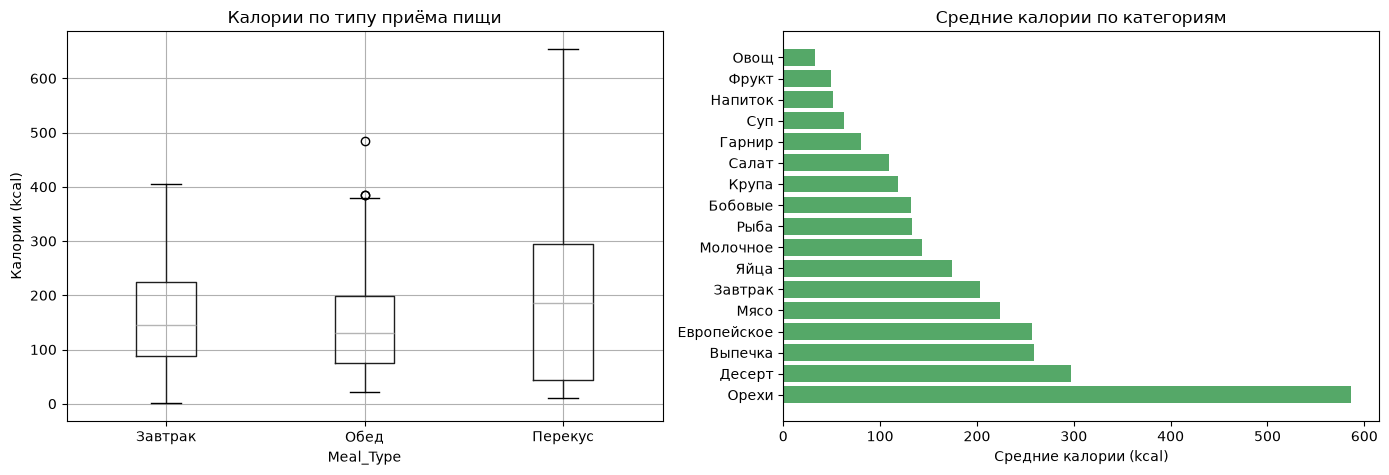

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='Calories (kcal)', by='Meal_Type', ax=axes[0])
axes[0].set_title('Калории по типу приёма пищи')
axes[0].set_xlabel('Meal_Type')
axes[0].set_ylabel('Калории (kcal)')
plt.suptitle('')

cat_means = df.groupby('Category_Grouped')['Calories (kcal)'].mean().sort_values(ascending=False)
axes[1].barh(cat_means.index, cat_means.values, color='#55A868')
axes[1].set_title('Средние калории по категориям')
axes[1].set_xlabel('Средние калории (kcal)')

plt.tight_layout()
plt.show()

**Вывод:** категория блюда хорошо различает калорийность - Орехи и Десерт в среднем самые калорийные, а Овощ и Фрукт - наименее калорийные. Это говорит о том, что признак Category_Grouped несёт полезную информацию для модели.
По типу приёма пищи медианные значения калорий у Завтрака и Обеда похожи, но разброс у Перекуса заметно шире - туда попадают как лёгкие продукты, так и калорийные десерты, поэтому эта категория более неоднородна.

## 6. Корреляция числовых признаков

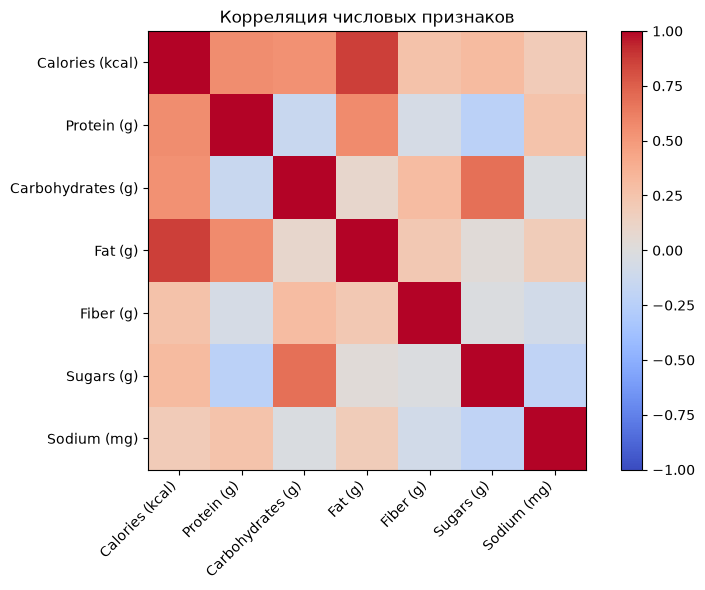

,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg)
Calories (kcal),1.000000,0.561696,0.534900,0.864620,0.264722,0.309809,0.188617
Protein (g),0.561696,1.000000,-0.145265,0.565381,-0.058544,-0.230566,0.254791
Carbohydrates (g),0.534900,-0.145265,1.000000,0.093124,0.304444,0.681790,-0.027729
Fat (g),0.864620,0.565381,0.093124,1.000000,0.211651,0.030848,0.187168
Fiber (g),0.264722,-0.058544,0.304444,0.211651,1.000000,-0.020887,-0.079303
Sugars (g),0.309809,-0.230566,0.681790,0.030848,-0.020887,1.000000,-0.202693
Sodium (mg),0.188617,0.254791,-0.027729,0.187168,-0.079303,-0.202693,1.000000


In [20]:
num_cols  = ['Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)', 'Sugars (g)', 'Sodium (mg)']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticklabels(num_cols)
plt.colorbar(im, fraction=0.046)
plt.title('Корреляция числовых признаков')
plt.tight_layout()
plt.show()

corr

Вывод: сильнее всего с калориями связаны жиры (0.86) - намного заметнее, чем белки (0.56) или углеводы (0.53). Сахар коррелирует с углеводами (0.68), так как является их подтипом, но слабо связан с калориями (0.31) и слегка отрицательно - с белком (-0.23). Натрий и клетчатка слабо коррелируют почти со всеми признаками (макс. 0.25–0.30) - это независимые сигналы, не дублирующие калорийность или макросостав, что делает их полезными для разметки по отдельным целям ("Баланс/ЗОЖ")

## 7. Общие выводы по EDA

1. Датасет содержит 400 блюд из 17 категорий, 10 признаков, пропущенных значений нет.
2. Калории, сахар, клетчатка и натрий имеют скошенное распределение 
3. Жиры сильнее всего коррелируют с калориями (0.86), сахар коррелирует с углеводами (0.68), но слабо с калориями (0.31) - 
4. Натрий и клетчатка слабо коррелируют с остальными признаками - независимые сигналы для целей "Баланс/ЗОЖ" и "Контроль сахара".
5. Категория и тип приёма пищи логично связаны с калорийностью -эти признаки полезны для модели.

